#### Imports

In [25]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import random
import matplotlib.pyplot as plt
import shutil


#### Initial Information

In [10]:
# Folder path for images
folder_path = '../10000_random_files'
output_path = '../10000_random_files_png_normalized'

In [3]:
# List to store image information
image_data = []

# Count images by file type
image_counts = {}

# Count non-grayscale images
non_grayscale_count = 0

# Loop through the files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):  # Different file extensions
        # Get the full path of the image
        img_path = os.path.join(folder_path, filename)
        
        # Open the image
        with Image.open(img_path) as img:
            # Check if the image is grayscale
            if img.mode != 'L':
                non_grayscale_count += 1  # Count non-grayscale images
                continue  # Skip if the image is not grayscale
            
            # Store the information
            img_type = filename.split('.')[-1]  # Image extension
            img_width, img_height = img.size
            
            # Add to the list
            image_data.append([filename, img_type, img_width, img_height])
            
            # Count images by type
            if img_type not in image_counts:
                image_counts[img_type] = 0
            image_counts[img_type] += 1

# Save the information to a CSV
df = pd.DataFrame(image_data, columns=['Filename', 'Type', 'Width', 'Height'])
df.to_csv('image_review.csv', index=False)

# Print the number of images of each type
print("Number of images of each type:")
for img_type, count in image_counts.items():
    print(f"{img_type}: {count} images")

# Print the count of non-grayscale images
print(f"Number of non-grayscale images: {non_grayscale_count}")

# Additional useful information you might want to check
print(f"Total number of images: {len(image_data)}")

Number of images of each type:
jpg: 8653 images
png: 1324 images
jpeg: 18 images
Number of non-grayscale images: 0
Total number of images: 9995


In [4]:
# Load the CSV file containing image information
df = pd.read_csv('image_review.csv')

# Group by width and height and count occurrences
size_counts = df.groupby(['Width', 'Height']).size().reset_index(name='Count')

# Print the size and count of each unique image dimension
for index, row in size_counts.iterrows():
    print(f"Size: {row['Width']}x{row['Height']} - Count: {row['Count']} images")


Size: 800x600 - Count: 9995 images


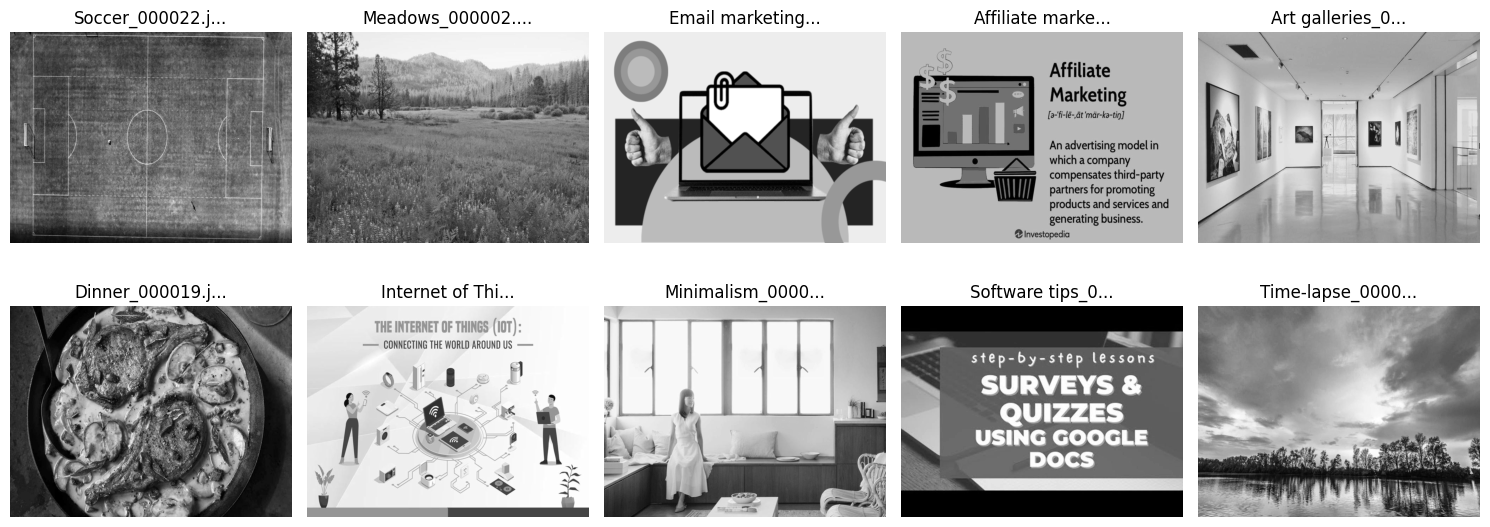

In [5]:
# Display 10 random grayscale images in 2 rows of 5
if len(image_data) >= 10:
    # Select 10 random images
    random_images = random.sample(image_data, 10)
    
    # Set up the plot with 2 rows and 5 columns
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    # Loop through the selected images and display them
    for i, (filename, img_type, width, height) in enumerate(random_images):
        img_path = os.path.join(folder_path, filename)
        with Image.open(img_path) as img:
            ax = axes[i // 5, i % 5]  # Determine position in 2x5 grid
            ax.imshow(img, cmap='gray')  # Display image in grayscale
            ax.axis('off')  # Turn off axis
            ax.set_title(f'{filename[:15]}...')  # Display first 15 characters of filename
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough images to display 10 random ones.")


#### PreProcessing

Converting image formats to a fixed format (Uniform Format Conversion) </br>
and </br>
Normalization

In [21]:
def convert_and_normalize(image_folder, image_name, output_folder):
    # Open the image
    image_path = os.path.join(image_folder, image_name)
    image = Image.open(image_path)
    
    # Convert to PNG if the image is not already PNG
    if image_path.split('.')[-1].lower() not in ['png']:
        new_path = os.path.join(output_folder, image_name.replace(image_path.split('.')[-1], 'png'))
        image.save(new_path, 'PNG')
    else:
        new_path = os.path.join(output_folder, image_name)
    
    # Normalize the image (convert pixel values to range [0, 1])
    image_array = np.array(image) / 255.0  # Normalize to range [0, 1]
    
    # Save the normalized image
    normalized_image = Image.fromarray((image_array * 255).astype(np.uint8))
    normalized_image.save(new_path)
    
    # return new_path

def process_images(input_folder, output_folder):
    # Check if the output folder exists, if not, create it
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Initialize a counter for tracking progress
    counter = 0
    
    # Process each image in the input folder
    for image_name in os.listdir(input_folder):
        if image_name.lower().endswith(('.jpg', '.jpeg', '.png')):  # Check for image extensions
            # Call the convert_and_normalize function to process the image
            # new_image_path = convert_and_normalize(input_folder, image_name, output_folder)
            convert_and_normalize(input_folder, image_name, output_folder)
            
            # Increment the counter
            counter += 1
            
            # Print the progress every 100 images
            if counter % 100 == 0:
                print(f"{counter} images processed so far.")
    
    # Print a final message when all images are processed
    print(f"Processing completed. Total images processed: {counter}")

In [22]:
process_images(folder_path, output_path)

100 images processed so far.
200 images processed so far.
300 images processed so far.
400 images processed so far.
500 images processed so far.
600 images processed so far.
700 images processed so far.
800 images processed so far.
900 images processed so far.
1000 images processed so far.
1100 images processed so far.
1200 images processed so far.
1300 images processed so far.
1400 images processed so far.
1500 images processed so far.
1600 images processed so far.
1700 images processed so far.
1800 images processed so far.
1900 images processed so far.
2000 images processed so far.
2100 images processed so far.
2200 images processed so far.
2300 images processed so far.
2400 images processed so far.
2500 images processed so far.
2600 images processed so far.
2700 images processed so far.
2800 images processed so far.
2900 images processed so far.
3000 images processed so far.
3100 images processed so far.
3200 images processed so far.
3300 images processed so far.
3400 images process

Saving new image's information in a new csv

In [23]:
def save_image_info(input_folder, output_csv):
    # List to store image information
    image_info = []
    
    # Process each image in the input folder
    for image_name in os.listdir(input_folder):
        image_path = os.path.join(input_folder, image_name)
        
        # Only process image files (jpg, jpeg, png)
        if image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            # Open the image
            image = Image.open(image_path)
            
            # Get image details
            image_type = image_path.split('.')[-1].lower()  # Type (png, jpg, jpeg)
            width, height = image.size  # Image width and height
            normalized = 'yes' if image_path.lower().endswith('.png') else 'no'  # Check if normalized (PNG assumed as normalized)
            
            # Append the details to the list
            image_info.append([image_name, image_type, normalized, width, height])
    
    # Create a DataFrame from the image information list
    df = pd.DataFrame(image_info, columns=['Filename', 'Type', 'Normalized', 'Width', 'Height'])
    
    # Save DataFrame to CSV
    df.to_csv(output_csv, index=False)

In [24]:
output_csv = 'preprocessed_image_review.csv'
save_image_info(output_path, output_csv)

ازینجا به بعد به دلیل محدودیت زمانی روش ها فقط روی 100 تا از داده ها اجرا شدن.

In [26]:
def select_random_images(input_folder, output_folder, num_images=100):
    # Create the output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Get the list of all image filenames in the input folder
    image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Randomly select 'num_images' number of images
    selected_images = random.sample(image_files, num_images)
    
    # Copy the selected images to the output folder
    for image in selected_images:
        image_path = os.path.join(input_folder, image)
        new_image_path = os.path.join(output_folder, image)
        shutil.copy(image_path, new_image_path)
        print(f"Image {image} copied to {output_folder}")

In [ ]:
input_folder = "path_to_input_folder"  # Replace with the path to your input folder
output_folder = "path_to_output_folder"  # Replace with the path to your output folder
select_random_images(input_folder, output_folder, num_images=100)